# Mapping the Potential Destructive Power of Wildfires Using Machine Learning
---
## Module 7: *Modeling and Tuning*
##### Version Number: 3.0
---
### Contents  
> 1. *Random Forest*
> 2. *KNN Classifier*
> 3. *Neural Network*
> 3. *XGBoost*
> 5. *Export Optimum Configurations*
---
### Notes
This module **automatically** finds the optimal configuration of models based on the average F1 score of all three categories.

**WARNING** this module is very computation heavy
- Start with a **baseline model** for comparison.
- Test with multi-classification **tree-based models** (Random Forest, XGBoost) and Neural Networks.
- Use kfold **cross-validation** to tune hyperparameters for each model.
- Export optimal models

---
### Inputs
- `X.csv`- cleaned and scaled main weather dataset
- `y.csv`- multiclass target (0,1,2)

---
### Outputs  

`model_parameters.csv` - optimal parameters for each of the three models

---
### User Created Dependencies

In [1]:
# Add the parent directory to the system path so "src" can be found
import sys
import os

sys.path.append(os.path.abspath(os.path.join('..')))


from src.model_utils import test_values

from src.model_utils import apply_balancing

---

### Third Party Dependencies

In [2]:
# Core Python libraries
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing and modeling
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import mean_squared_error, r2_score
import xgboost as xgb
from lightgbm import LGBMClassifier

# Resampling tools
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import SMOTE

# Style
sns.set(style='whitegrid')
plt.rcParams["figure.dpi"] = 100

---

### Load File

In [3]:
# Load processed feature and label data
#best_strategy = pd.read_csv('../data/processed/best_strategy.csv')
X = pd.read_csv('../data/processed/X_scaled.csv')
y = pd.read_csv('../data/processed/y_reduced.csv').squeeze()

In [4]:
best_strategy = pd.read_csv('../data/processed/best_strategy.csv')

In [5]:
best_strategy

,Model_Label,Best_Strategy
0,LGBM,No_balance
1,XGB,Oversampling
2,RF,Undersampling


---

## 1. Random Forest Classifier

This section evaluates Hypertuning and class-balancing options for SciKitLearns **RandomForestClassifier**. Options are tested utilizing kfold validation. 
- `n_estimators` [50, 100, 150]
- `max_depth` [5, 10, 15, 20]
- `min_samples_split_values` = [2, 5, 10, 20, 50]
- `max_features` ['sqrt', 'log2']

In [6]:
X_train,y_train = apply_balancing('RF', best_strategy, X, y)

### 1.1 Hyperparameter Tuning

#### Number of Estimators (n_estimators)

RF: n_estimators = 50 | Average F1 score = 0.6806
RF: n_estimators = 100 | Average F1 score = 0.6786
RF: n_estimators = 150 | Average F1 score = 0.6788


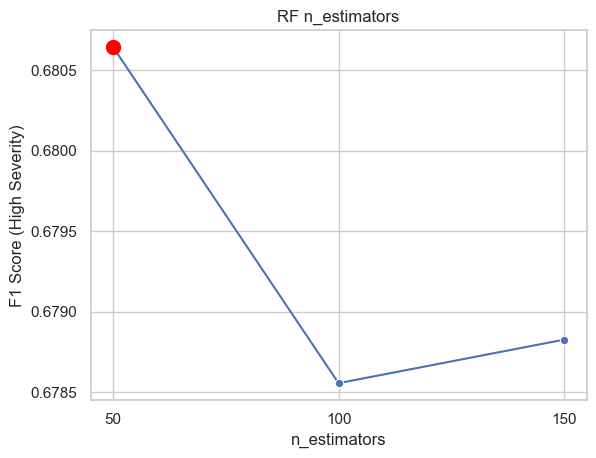

In [7]:
# Define parameter grid
estimators = [50, 100, 150]
optimum_n_estimator = test_values('RF','n_estimators',estimators,X_train, y_train)

optimum_n_estimator

#### Maximum Tree Depth (max_depth)

RF: max_depth = 5 | Average F1 score = 0.6380
RF: max_depth = 10 | Average F1 score = 0.6801
RF: max_depth = 15 | Average F1 score = 0.6781
RF: max_depth = 20 | Average F1 score = 0.6839


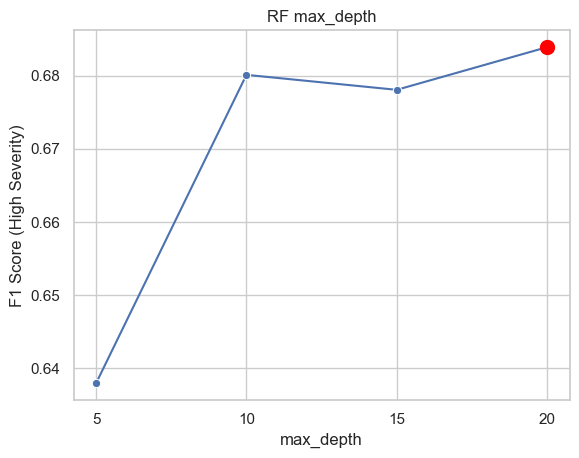

In [8]:
# Define parameter grid
max_depth = [5, 10, 15, 20] 
optimum_max_depth = test_values('RF','max_depth',max_depth,X_train, y_train)

In [9]:
optimum_max_depth

20

#### Maximum Features (max_features)

RF: max_features = sqrt | Average F1 score = 0.6742
RF: max_features = log2 | Average F1 score = 0.6644


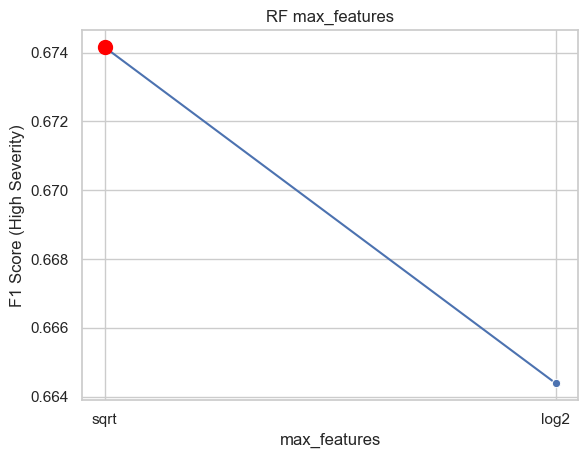

In [10]:
# Define parameter grid
max_features = ['sqrt', 'log2']
optimum_max_features = test_values('RF','max_features',max_features,X_train, y_train)

In [11]:
optimum_max_features

'sqrt'

#### Minimum Sample Split  (min_samples)

RF: min_samples_split = 2 | Average F1 score = 0.6770
RF: min_samples_split = 5 | Average F1 score = 0.6799
RF: min_samples_split = 10 | Average F1 score = 0.6770
RF: min_samples_split = 20 | Average F1 score = 0.6820
RF: min_samples_split = 50 | Average F1 score = 0.6716


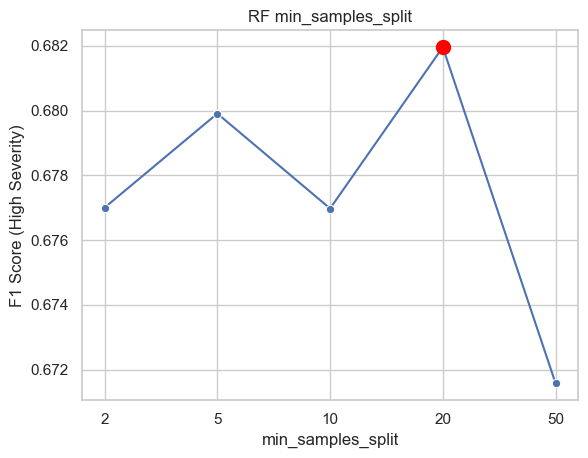

In [12]:
# Define parameter grid
min_samples_split_values = [2, 5, 10, 20, 50] 
optimum_min_samples_split = test_values('RF','min_samples_split',min_samples_split_values,X_train, y_train)

### 1.2 Final Random Forest Model

In [13]:
RF_parameters = {
    'n_estimators': optimum_n_estimator,
    'max_depth': optimum_max_depth,
    'min_samples_split': optimum_min_samples_split,
    'max_features': optimum_max_features,
    'class_weight':'balanced'
}

optimum_rf = RandomForestClassifier(**RF_parameters)

# Create DataFrame and format display
pd.DataFrame([RF_parameters]).style \
    .hide(axis='index') \
    .set_caption("Optimum Random Forest Parameters")

n_estimators,max_depth,min_samples_split,max_features,class_weight
50,20,20,sqrt,balanced


---

## 2. LGBM

In [14]:
X_train,y_train = apply_balancing('LGBM', best_strategy, X, y)

LGBM: n_estimators = 50 | Average F1 score = 0.7157
LGBM: n_estimators = 100 | Average F1 score = 0.7152
LGBM: n_estimators = 150 | Average F1 score = 0.7136


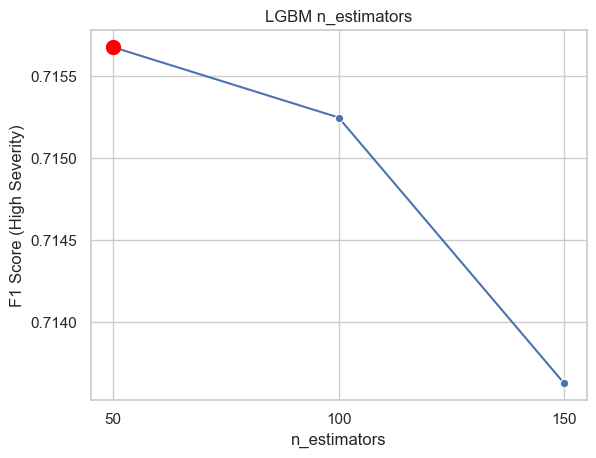

In [15]:
estimators = [50, 100, 150]
optimum_n_estimator = test_values('LGBM','n_estimators',estimators,X_train, y_train)

LGBM: num_leaves = 15 | Average F1 score = 0.7186
LGBM: num_leaves = 31 | Average F1 score = 0.7162
LGBM: num_leaves = 63 | Average F1 score = 0.7178
LGBM: num_leaves = 127 | Average F1 score = 0.7198
LGBM: num_leaves = 255 | Average F1 score = 0.7198


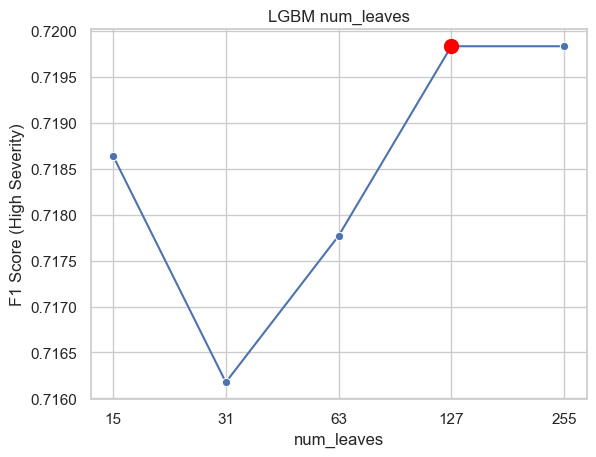

In [16]:
# Define parameter grid
num_leaves = [15, 31, 63, 127, 255]
optimum_num_leaves = test_values('LGBM','num_leaves', num_leaves, X_train, y_train)

LGBM: max_depth = -1 | Average F1 score = 0.7162
LGBM: max_depth = 3 | Average F1 score = 0.7069
LGBM: max_depth = 5 | Average F1 score = 0.7139
LGBM: max_depth = 7 | Average F1 score = 0.7184
LGBM: max_depth = 9 | Average F1 score = 0.7121
LGBM: max_depth = 11 | Average F1 score = 0.7119


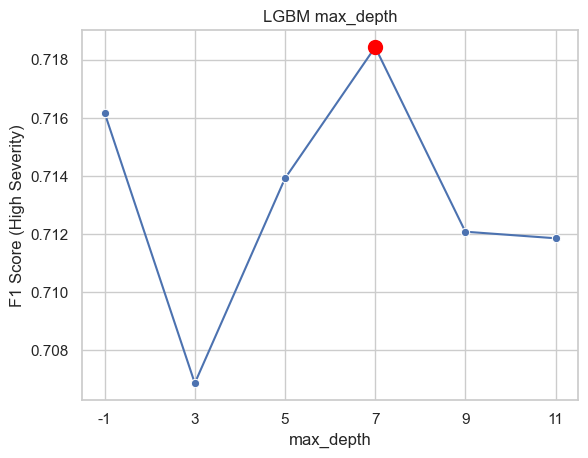

In [17]:
max_depth = [-1, 3, 5, 7, 9, 11]
optimum_max_depth = test_values('LGBM','max_depth',max_depth,X_train, y_train)

LGBM: learning_rate = 50 | Average F1 score = 0.2812
LGBM: learning_rate = 100 | Average F1 score = 0.1780
LGBM: learning_rate = 150 | Average F1 score = 0.2023


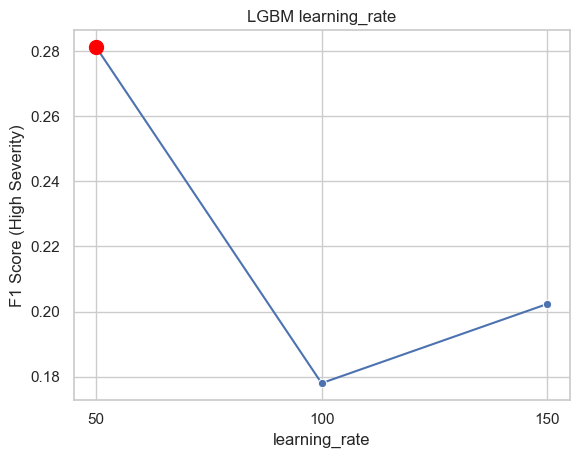

In [18]:
learning_rate = [50, 100, 150]
optimum_learning_rate = test_values('LGBM','learning_rate',learning_rate,X_train, y_train)

In [24]:
lgbm_params = {
    'n_estimators' : optimum_n_estimator,
    'num_leaves' : optimum_num_leaves,
    'max_depth':optimum_max_depth,
    'learning_rate':optimum_learning_rate,
    'class_weight':'balanced',
    'verbose' : -1
}
        

optimum_lgbm = LGBMClassifier(**lgbm_params)

# Create DataFrame and format display
pd.DataFrame([lgbm_params]).style \
    .hide(axis='index') \
    .set_caption("Optimum LightGBM Parameters")

n_estimators,num_leaves,max_depth,learning_rate,class_weight,verbose
150,127,7,0.100000,balanced,-1


---

## 3. XGBoost Classifier

This section trains an XGBoost classifier using grid-based hyperparameter tuning and evaluates performance under different sampling strategies.

In [25]:
X_train,y_train = apply_balancing('XGB', best_strategy, X, y)

### 3.2 Hyperparameter Tuning

#### n_estimators Tuning

XGB: n_estimators = 50 | Average F1 score = 0.6970
XGB: n_estimators = 100 | Average F1 score = 0.7101
XGB: n_estimators = 150 | Average F1 score = 0.7150
XGB: n_estimators = 200 | Average F1 score = 0.7124


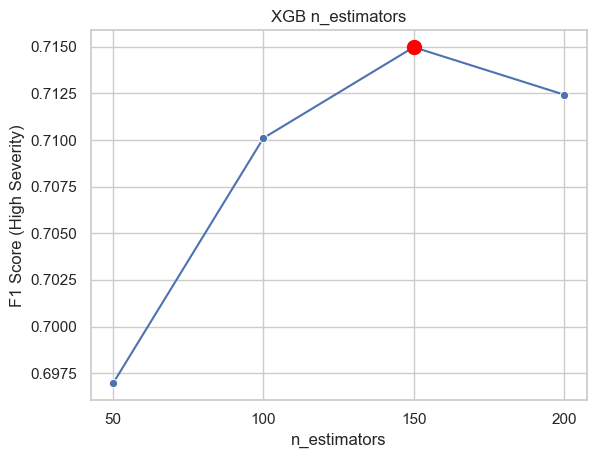

In [26]:
n_estimators = [50, 100, 150, 200]
optimum_n_estimator = test_values('XGB','n_estimators', n_estimators, X_train, y_train)

#### learning_rate Tuning

XGB: learning_rate = 0.1 | Average F1 score = 0.7209
XGB: learning_rate = 0.2 | Average F1 score = 0.7075
XGB: learning_rate = 0.3 | Average F1 score = 0.7126
XGB: learning_rate = 0.4 | Average F1 score = 0.7050


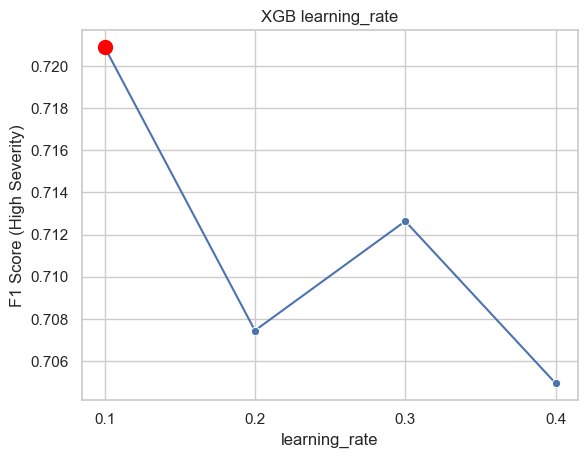

In [27]:
learning_rates = [0.1, 0.2, 0.3, 0.4]
optimum_learning_rate = test_values('XGB','learning_rate', learning_rates, X_train, y_train)

#### max_depth Tuning

XGB: max_depth = 3 | Average F1 score = 0.7068
XGB: max_depth = 4 | Average F1 score = 0.7124
XGB: max_depth = 5 | Average F1 score = 0.7187
XGB: max_depth = 6 | Average F1 score = 0.7196


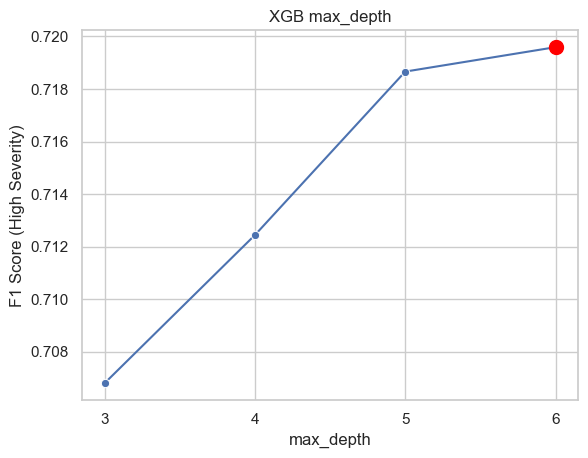

In [28]:
max_depths = [3, 4, 5, 6]
optimum_max_depth = test_values('XGB','max_depth', max_depths, X_train, y_train)

### 3.3 Final XGBoost Model

In [29]:
XGB_parameters = {
    'objective': 'multi:softmax',
    'num_class': 3,
    'n_estimators': optimum_n_estimator,
    'max_depth': optimum_max_depth,
    'learning_rate': optimum_learning_rate,
    'verbosity': 0
}


optimum_xgb_model = xgb.XGBClassifier(
    **XGB_parameters
)

# Create DataFrame and format display
pd.DataFrame([XGB_parameters]).style \
    .hide(axis='index') \
    .set_caption("Optimum XGBoost Parameters")

objective,num_class,n_estimators,max_depth,learning_rate,verbosity
multi:softmax,3,150,6,0.100000,0


---

## 4. Export Data

In [32]:
model_params = {
    'RandomForest': RF_parameters,
    'XGBoost': XGB_parameters,
    'LGBM': lgbm_params,
}
# Flatten the dict into a DataFrame
model_parameters = pd.DataFrame.from_dict(model_params, orient='index')


In [33]:
# Save to CSV
model_parameters.to_csv('../data/processed/model_parameters.csv')
print("All datasets saved successfully to ../data/processed/")

All datasets saved successfully to ../data/processed/
